In [1]:
# ==
# 1. Import Libraries
# ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
# ==
# 2. Generate Larger Farming Dataset (8 Features)
# =====
np.random.seed(42)
n_samples =60
data = {
'Weather': np.random.choice(['Sunny','Cloudy','Rainy'], n_samples),
'Soil': np.random.choice(['Dry','Moist','Wet'], n_samples),
'Temperature': np.random.choice(['Hot','Mild','Cool'], n_samples),
'Humidity': np.random.choice(['High','Medium','Low'], n_samples),
'Wind': np.random.choice(['Strong','Weak'], n_samples),
'Fertilizer': np.random.choice(['Yes','No'], n_samples),
'Crop Type': np.random.choice(['Wheat','Rice','Corn'], n_samples),
'Season': np.random.choice(['Kharif','Rabi','Summer'], n_samples)

}
df=pd.DataFrame(data)


In [6]:
# Step 3 Create target varieble(rule based for realism)

def irrigation_rule(row):
  if row["Soil"]=="Dry" and row["Weather"]!="Rainy":
    return "Yes"
  elif  row["Soil"]=="Wet":
    return "No"
  elif row["Humidity"]=="High" and row["Weather"]=="Rainy":
    return "No"
  else:
    return np.random.choice(["Yes","No"])
df["Irrigate"]=df.apply(irrigation_rule,axis=1)

print("Sample dataset:\n",df.head())

# Step 4 : Encode categorical value
le_dict={}
for column in df.columns:
  le=LabelEncoder()
  df[column]=le.fit_transform(df[column])
  le_dict[column]=le

#  Step 5 : Split features and target

X=df.drop("Irrigate",axis=1)
y=df["Irrigate"]

# Step 6 Train_test split(Stratified)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)


# Decision tree model

dt_model=DecisionTreeClassifier(criterion="entropy",random_state=42)
dt_model.fit(X_train,y_train)

y_pred_dt=dt_model.predict(X_test)

# Step 8 Random forest classication model

rf_model=RandomForestClassifier(n_estimators=20,criterion="entropy",random_state=42)
rf_model.fit(X_train,y_train)
y_pred_rf=rf_model.predict(X_test)

# step 9 Accuracy evaluation
dt_accuracy=accuracy_score(y_test,y_pred_dt)
rf_accuracy=accuracy_score(y_test,y_pred_rf)

print("\n Accuracy Comparision:")
print("Decision Tree Accuracy:",dt_accuracy)
print("Random Forest Accuracy",rf_accuracy)


Sample dataset:
    Weather  Soil  Temperature  Humidity  Wind  Fertilizer  Crop Type  Season  \
0        1     1            1         0     1           1          0       1   
1        2     0            0         1     1           1          1       1   
2        1     1            2         2     0           1          1       0   
3        1     1            0         0     0           1          1       0   
4        2     1            0         0     1           0          1       0   

  Irrigate  
0       No  
1      Yes  
2      Yes  
3       No  
4       No  

 Accuracy Comparision:
Decision Tree Accuracy: 0.3333333333333333
Random Forest Accuracy 0.5


In [3]:
# step 10 Confusion matrix (FIXED and MEaning ful)

cm_dt=confusion_matrix(y_test,y_pred_dt,labels=[0,1])
cm_rf=confusion_matrix(y_test,y_pred_dt,labels=[0,1])

cm_dt_df=pd.DataFrame(cm_dt,index=["Actual No","Actual Yes"],columns=["Pred No","Pred yes"])
cm_rf_df=pd.DataFrame(cm_rf,index=["Actual no","Actual Yes"],columns=["Pred No","Pred Yes"])
print("\n Decision Tree Confusion matrix:\n",cm_dt_df)
print("\n Random Forest Confusion matrix:\n",cm_rf_df)



 Decision Tree Confusion matrix:
             Pred No  Pred yes
Actual No         8         3
Actual Yes        1         6

 Random Forest Confusion matrix:
             Pred No  Pred Yes
Actual no         8         3
Actual Yes        1         6


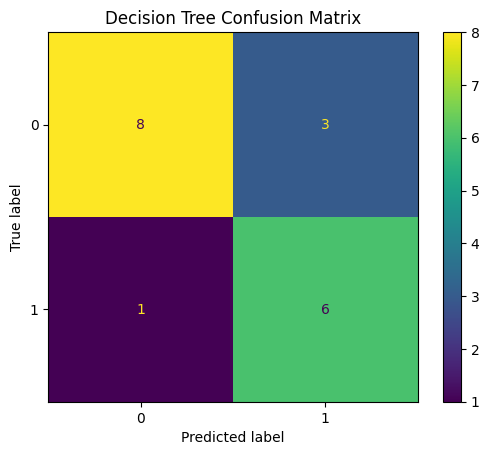

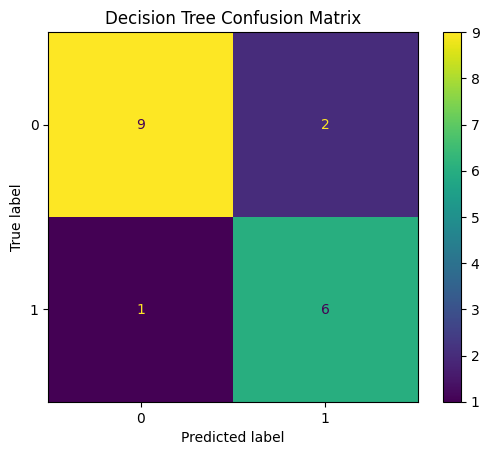

In [4]:
#Step 11: Confusion MAtrix Visualization

ConfusionMatrixDisplay.from_predictions(y_test,y_pred_dt,labels=[0,1])
plt.title("Decision Tree Confusion Matrix")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test,y_pred_rf,labels=[0,1])
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [5]:
# STep 12 Cross validation
dt_cv=cross_val_score(dt_model,X,y,cv=5)
rf_cv=cross_val_score(rf_model,X,y,cv=5)

print("\n Cross Validation Accuracy:")
print("Decision Tree:",dt_cv.mean())
print("Random Forest:",rf_cv.mean())

# Step 13 Feature Importance (RAndom Forest)

importance=pd.DataFrame({"Feature":X.columns,"Importance":rf_model.feature_importances_}).sort_values(by="Importance",ascending=False)

print("\n Feature Importance :\n",importance)


 Cross Validation Accuracy:
Decision Tree: 0.8
Random Forest: 0.8

 Feature Importance :
        Feature  Importance
1         Soil    0.357601
3     Humidity    0.131258
0      Weather    0.115746
7       Season    0.094661
5   Fertilizer    0.090702
4         Wind    0.075124
6    Crop Type    0.067936
2  Temperature    0.066970
